In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import LabelBinarizer, RobustScaler, StandardScaler, MinMaxScaler, QuantileTransformer, PowerTransformer
from sklearn.cluster import DBSCAN, KMeans
from sklearn import metrics
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [2]:
from sklearn.metrics import adjusted_rand_score

In [3]:
df_complete = pd.read_csv('df_selected_data.csv')

In [4]:
import time
from datetime import datetime, date, timedelta

In [5]:
df_complete.columns

Index(['Unnamed: 0', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_id', 'order_purchase_timestamp', 'price',
       'review_id', 'review_score', 'review_comment_message'],
      dtype='object')

In [6]:
df_complete

,Unnamed: 0,customer_id,customer_unique_id,customer_city,customer_state,order_id,order_purchase_timestamp,price,review_id,review_score,review_comment_message
0,0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,124.99,88b8b52d46df026a9d1ad2136a59b30b,4,NaN
1,1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,289.00,02fc48a9efa3e3d0f1a8ea26507eeec3,5,NaN
2,2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,139.94,5ad6695d76ee186dc473c42706984d87,5,NaN
3,3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,149.94,059a801bb31f6aab2266e672cab87bc5,5,NaN
4,4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,230.00,8490879d58d6c5d7773f2739a03f089a,5,O baratheon è esxelente Amo adoro o baratheon
...,...,...,...,...,...,...,...,...,...,...,...
112367,112367,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,2018-04-07 15:48:17,74.90,36e2cdbaa9f639b57c53b37ac798fee8,4,NaN
112368,112368,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,2018-04-04 08:20:22,114.90,b273b431c3aedb4eed18643309652940,5,NaN
112369,112369,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,2018-04-08 20:11:50,37.00,fa4f16891e6b2edd1354668d07f5648b,1,Esperava qualidade no atendimento e estou tend...
112370,112370,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,2017-11-03 21:08:33,689.00,0bcdc9e450ea500811a8d39ee993cd47,5,NaN


In [7]:
df_complete['order_purchase_timestamp'].dtypes

dtype('O')

In [8]:
# Faire une fonction qui renvoie les données sous forme de RFM en fonction de la date
def data(df_complete, date_finale):
    """Retourne le dataframe contenant les données RFM jusqu'à la date_finale indiquée"""

    # sélectionner les données qui ont la bonne date
    df_complete['order_purchase_timestamp'] = pd.to_datetime(
        df_complete['order_purchase_timestamp'])
    df_sel = df_complete.loc[
        df_complete['order_purchase_timestamp'] < date_finale]

    # Traiter les données pour obtenir les features du RFM

    # Créer la feature nombre de commandes : F
    df_sel['number_of_orders'] = 1
    columns = ['customer_unique_id', 'number_of_orders']
    df = pd.DataFrame(columns=columns)
    df['number_of_orders'] = df_sel.groupby(
        by='customer_unique_id')['number_of_orders'].sum()
    df.drop(['customer_unique_id'], axis=1)

    # Créer la feature somme des commandes : M
    df['sum_price'] = df_sel.groupby(by='customer_unique_id')['price'].sum()

    # Créer la feature nombre de jours depuis la dernière commande R
    df['last_order'] = df_sel.groupby(
        by='customer_unique_id')['order_purchase_timestamp'].max()
    df['last_order'] = pd.to_datetime(df['last_order'])
    df['elapsed_time_days'] = (pd.to_datetime(date_finale) -
                               df['last_order']).dt.days

    # Créer le dataframe RFM
    selection = ['elapsed_time_days', 'number_of_orders', 'sum_price']
    df_final = df[selection]

    return df_final

In [9]:
data(df_complete, '2017-12-31 23:59:59')

C:\Users\LN6428\AppData\Local\Temp\ipykernel_13360\3310562189.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['number_of_orders'] = 1


,elapsed_time_days,number_of_orders,sum_price
customer_unique_id,,,
0000f46a3911fa3c0805444483337064,296,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,80,1,25.99
0004aac84e0df4da2b147fca70cf8255,47,1,180.00
0005e1862207bf6ccc02e4228effd9a0,302,1,135.00
0006fdc98a402fceb4eb0ee528f6a8d4,166,1,13.90
...,...,...,...
fffbf87b7a1a6fa8b03f081c5f51a201,4,1,149.00
fffcf5a5ff07b0908bd4e2dbc735a684,206,2,1570.00
fffea47cd6d3cc0a88bd621562a9d061,21,1,64.89


In [10]:
# Initialiser au 31 décembre 2017
date_0 = pd.to_datetime('2017-12-31 23:59:59')

In [11]:
# Faire la liste des dates
dates = [date_0 + i * timedelta(days=7) for i in range(0, 21)]

In [12]:
# Faire la liste des dataframes
df = [data(df_complete, dates[i]) for i in range(0, len(dates))]

C:\Users\LN6428\AppData\Local\Temp\ipykernel_13360\3310562189.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['number_of_orders'] = 1
C:\Users\LN6428\AppData\Local\Temp\ipykernel_13360\3310562189.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel['number_of_orders'] = 1
C:\Users\LN6428\AppData\Local\Temp\ipykernel_13360\3310562189.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [13]:
# Fit avec les premières données
# Standardisation des données
S0 = StandardScaler().fit(df[0])

In [14]:
M0 = KMeans(n_clusters=4, random_state=5).fit(S0.transform(df[0]))

In [15]:
C0 = M0.predict(S0.transform(df[0]))

In [16]:
# Pour les df suivants entrainer un nouveau modèle et le comparer sur le df initial

In [17]:
S1 = StandardScaler().fit(df[1])
M1 = KMeans(n_clusters=4, random_state=5).fit(S1.transform(df[1]))
C1 = M1.predict(S1.transform(df[1]))

In [18]:
C1_0 = M0.predict(S0.transform(df[1]))

In [19]:
adjusted_rand_score(C1, C1_0)

0.9596417514545679

In [20]:
# Standardisations
S = [StandardScaler().fit(df[i]) for i in range(0, len(dates))]

In [21]:
# Création des modèles
M = [
    KMeans(n_clusters=4, random_state=5).fit(S[i].transform(df[i]))
    for i in range(0, len(dates))
]

In [22]:
# Clustering
C = [M[i].predict(S[i].transform(df[i])) for i in range(0, len(dates))]

In [23]:
# Clustering en utilisant le modèle initial
Ci = [M[0].predict(S[0].transform(df[i])) for i in range(0, len(dates))]

In [24]:
ARI = [adjusted_rand_score(C[i], Ci[i]) for i in range(0, len(dates))]

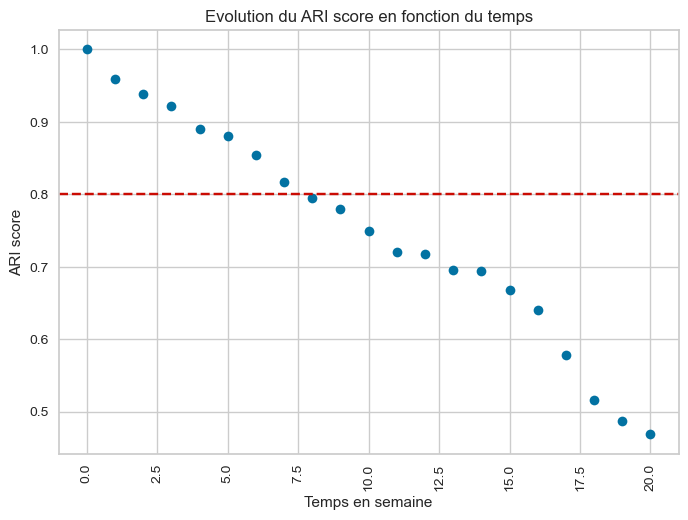

In [36]:
plt.title('Evolution du ARI score en fonction du temps')
plt.plot(ARI, 'bo')
plt.axhline(0.8, ls='--', c='r')
plt.xticks(rotation='vertical')
plt.ylabel('ARI score')
plt.xlabel('Temps en semaine')
plt.show()

In [26]:
# Modèle obsolète ARI < 0.8 après 8 semaines
#donc contrat de maintenance proposé : mettre à jour le modèle toutes les 8 semaines